# Results analyzer

This notebook analyzes the results of the simheuristic experiments in detail.
It loads the results from CSV files, summarizes the data, performs significance testing, and visualizes the results.
It also plots Gantt charts for the solutions found by the simheuristics.

In comparison to results_comparator.ipynb, this notebook focuses on the results of the simheuristics in more detail.

In [1]:
from pathlib import Path

import pandas as pd

# Data loading

In [2]:
# Choose what you would like to analyze
b_with_tardiness = False
b_full_stochasticity = False

DATA_DIR = Path("../results")
if b_full_stochasticity:
    if b_with_tardiness:
        file_names = [
            "OpenShop_2025-04-26_11-47-08.csv",
            "ParallelMachines_2025-04-26_11-47-24.csv",
            "HybridFlowShop_2025-04-26_11-46-52.csv",
            "JobShop_2025-04-26_11-46-25.csv",
            "FlexibleJobShop_2025-04-26_11-46-23.csv",
            ]  # task durations all random and with tardiness
    else:
        file_names = [
            "OpenShop_2025-04-27_15-11-18.csv",
            "ParallelMachines_2025-04-27_15-11-05.csv",
            "HybridFlowShop_2025-04-27_15-11-16.csv",
            "JobShop_2025-04-27_15-11-22.csv",
            "FlexibleJobShop_2025-04-27_15-11-36.csv",
            ]  # task durations all random and NO tardiness
else:
    if b_with_tardiness:
        file_names = [
            "OpenShop_2025-04-25_15-57-54.csv",
            "ParallelMachines_2025-04-25_15-58-06.csv",
            "HybridFlowShop_2025-04-25_15-57-28.csv",
            "JobShop_2025-04-25_19-18-49.csv",
            "FlexibleJobShop_2025-04-25_19-18-58.csv",
            ]  # a task duration is random with probability 0.3
    else:
        file_names = [
            "OpenShop_2025-04-27_15-13-33.csv",
            "ParallelMachines_2025-04-27_15-13-43.csv",
            "HybridFlowShop_2025-04-27_15-13-25.csv",
            "JobShop_2025-04-27_15-13-14.csv",
            "FlexibleJobShop_2025-04-27_15-13-10.csv",
            ]  # no tardiness
dfs = {}
for file_name in file_names:
    dfs[file_name] = pd.read_csv(DATA_DIR / file_name)
    # display(dfs[file_name].head(4))

# Summary statistics

In [3]:
numeric_cols = [
    "mean",
    "num_sims",
    "DCOP_objective",
    "solver_phase_dur",
    "final_sim_phase_dur",
    "total_exp_dur",
]

for file_name, df in dfs.items():

    # Convert numeric columns to proper types (in case they were read as strings)
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # Group by simheuristic and take the mean of selected columns
    agg_results = df.groupby("simheuristic")[numeric_cols].mean().round(2)

    # Count number of feasible experiments per simheuristic
    feasible_counts = (
        df[df["solve status"] == "Feasible"]
        .groupby("simheuristic")
        .size()
        .rename("num_feasible")
    )

    # Merge aggregated stats with feasible count
    summary = agg_results.merge(
        feasible_counts, on="simheuristic", how="left"
    ).fillna(0)

    # Show nicely in notebook
    display(summary.style.set_caption(f"Summary per Simheuristic for {file_name}"))

,mean,num_sims,DCOP_objective,solver_phase_dur,final_sim_phase_dur,total_exp_dur,num_feasible
simheuristic,,,,,,,
det_opt,8352.920000,1000.000000,7821.850000,300.170000,0.000000,300.170000,20
dyn_simh,8417.900000,1000.000000,8051.000000,270.440000,29.630000,300.060000,20
sim_last,8359.070000,1000.000000,7834.250000,270.190000,29.870000,300.060000,20
std_simh,8406.900000,1000.000000,7907.850000,270.230000,29.830000,300.050000,20


,mean,num_sims,DCOP_objective,solver_phase_dur,final_sim_phase_dur,total_exp_dur,num_feasible
simheuristic,,,,,,,
det_opt,76.580000,1000.000000,73.450000,300.360000,0.000000,300.360000,20
dyn_simh,74.930000,1000.000000,72.700000,270.400000,29.640000,300.030000,20
sim_last,78.210000,1000.000000,75.100000,270.370000,29.660000,300.030000,20
std_simh,77.140000,1000.000000,74.100000,270.360000,29.670000,300.030000,20


,mean,num_sims,DCOP_objective,solver_phase_dur,final_sim_phase_dur,total_exp_dur,num_feasible
simheuristic,,,,,,,
det_opt,157.450000,1000.000000,145.500000,300.170000,0.000000,300.170000,20
dyn_simh,156.570000,1000.000000,148.500000,270.230000,29.810000,300.040000,20
sim_last,157.610000,1000.000000,145.850000,270.160000,29.880000,300.040000,20
std_simh,157.280000,1000.000000,145.700000,270.160000,29.880000,300.040000,20


,mean,num_sims,DCOP_objective,solver_phase_dur,final_sim_phase_dur,total_exp_dur,num_feasible
simheuristic,,,,,,,
det_opt,12313.290000,1000.000000,11814.300000,300.130000,0.000000,300.130000,20
dyn_simh,12564.060000,1000.000000,12221.250000,270.340000,29.710000,300.040000,20
sim_last,12335.720000,1000.000000,11856.250000,270.130000,29.920000,300.050000,20
std_simh,12408.090000,1000.000000,11945.200000,270.260000,29.800000,300.060000,20


,mean,num_sims,DCOP_objective,solver_phase_dur,final_sim_phase_dur,total_exp_dur,num_feasible
simheuristic,,,,,,,
det_opt,150.820000,1000.000000,142.400000,300.240000,0.000000,300.240000,20
dyn_simh,154.470000,1000.000000,147.350000,270.420000,29.630000,300.050000,20
sim_last,150.850000,1000.000000,142.550000,270.240000,29.820000,300.060000,20
std_simh,152.280000,1000.000000,144.150000,270.250000,29.810000,300.060000,20


# Detailed results scatterplot

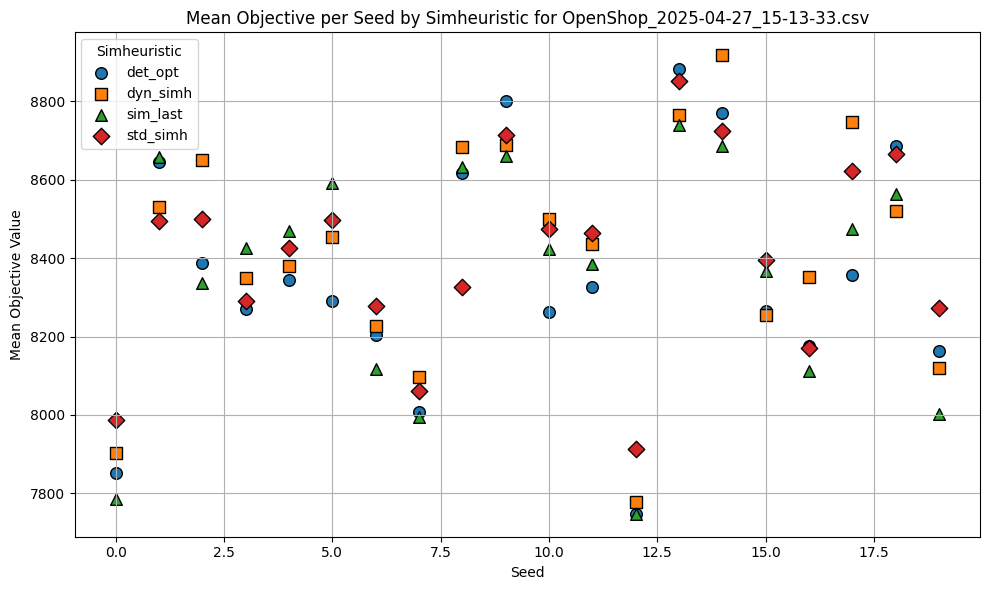

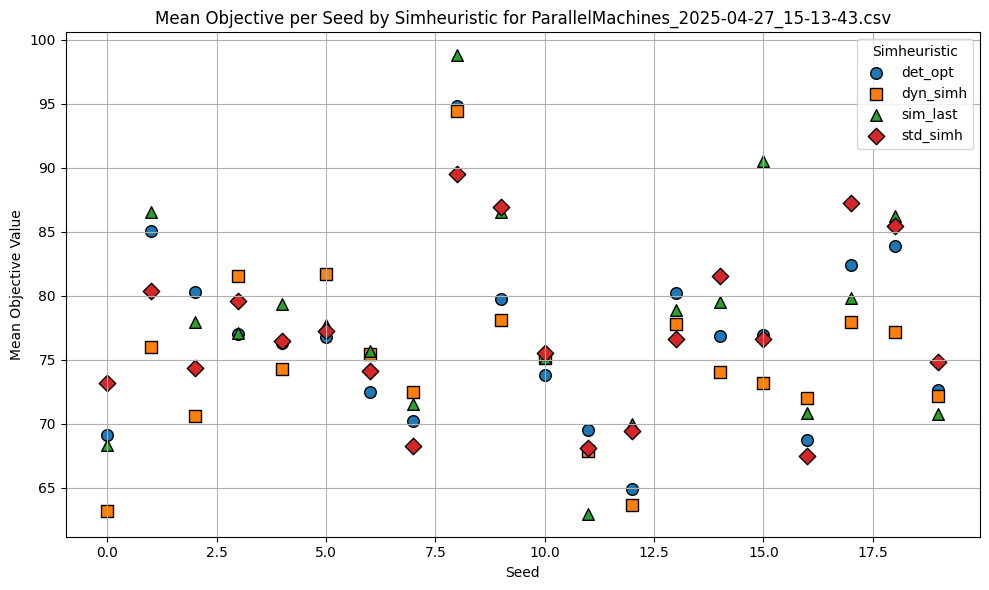

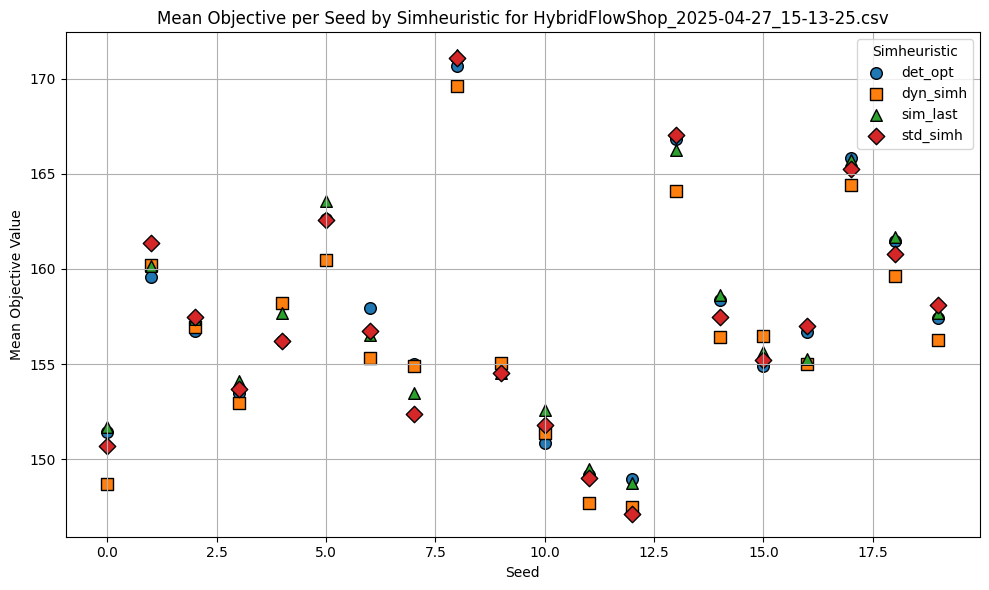

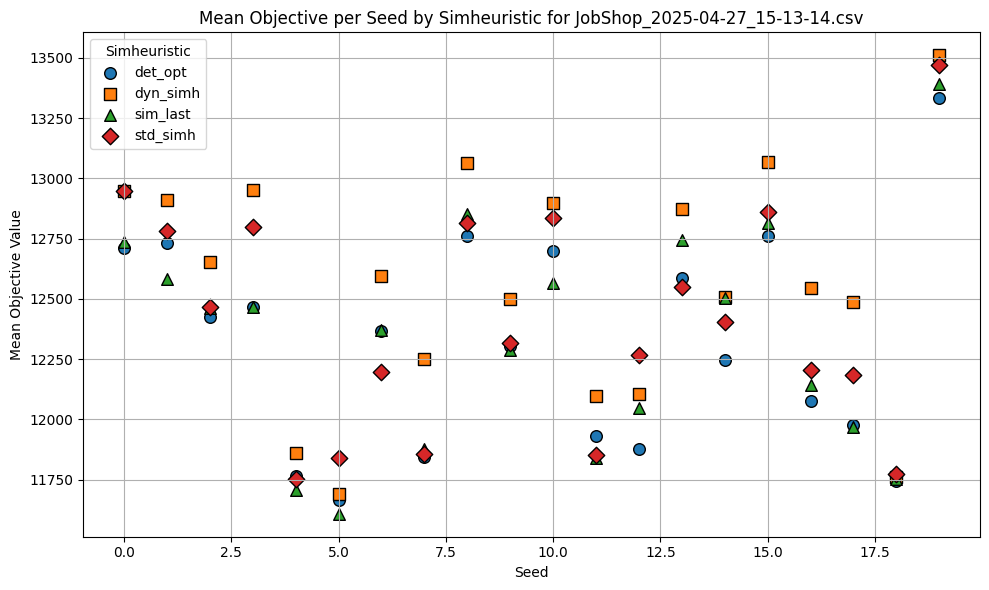

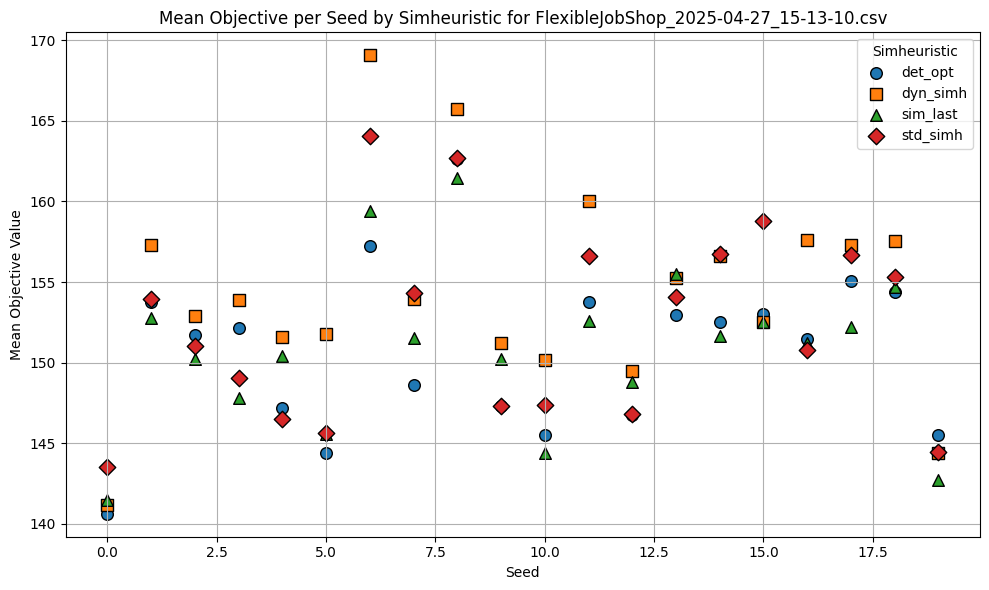

In [4]:
import matplotlib.pyplot as plt

for file_name, df in dfs.items():

    fig, ax = plt.subplots(figsize=(10, 6))

    # Optional: set color/marker styles for clarity
    markers = ["o", "s", "^", "D", "v", "*", "x"]
    colors = plt.cm.tab10.colors  # Up to 10 unique colors

    for i, (simh, group) in enumerate(df.groupby("simheuristic")):
        ax.scatter(
            group["seed"],
            group["mean"],
            label=simh,
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            s=70,
            edgecolor="black",
        )

    # Set labels and legend
    ax.set_title(f"Mean Objective per Seed by Simheuristic for {file_name}")
    ax.set_xlabel("Seed")
    ax.set_ylabel("Mean Objective Value")
    ax.legend(title="Simheuristic")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

# Significance testing

In [5]:
from itertools import combinations

from scipy.stats import ttest_rel

# Your significance level
alpha = 0.05

for file_name, df in dfs.items():

    # Prepare data
    pivot = df.pivot(index="seed", columns="simheuristic", values="mean")
    methods = pivot.columns
    results = pd.DataFrame(index=methods, columns=methods)

    # Pairwise t-tests
    p_values = {}
    for m1, m2 in combinations(methods, 2):
        stat, p = ttest_rel(pivot[m1], pivot[m2])
        p_values[(m1, m2)] = p

    # Multiple testing Sidak correction
    n_tests = 3
    alpha_correct = 1 - (1 - alpha) ** (1 / n_tests)
    print(f"Significance tests for {file_name} "
          f"(corrected significance level (Sidak): {alpha_correct:.4f})")

    # Fill in matrix
    for m1 in methods:
        for m2 in methods:
            if m1 == m2:
                results.loc[m1, m2] = "-"
            elif (m1, m2) in p_values:
                p = p_values[(m1, m2)]
                results.loc[m1, m2] = f"{p:.4f}{'*' if p < alpha_correct else ''}"
            elif (m2, m1) in p_values:
                p = p_values[(m2, m1)]
                results.loc[m1, m2] = f"{p:.4f}{'*' if p < alpha_correct else ''}"
    display(results)

Significance tests for OpenShop_2025-04-27_15-13-33.csv (corrected significance level (Sidak): 0.0170)


simheuristic,det_opt,dyn_simh,sim_last,std_simh
simheuristic,,,,
det_opt,-,0.0527,0.8263,0.0872
dyn_simh,0.0527,-,0.0639,0.7187
sim_last,0.8263,0.0639,-,0.1380
std_simh,0.0872,0.7187,0.1380,-


Significance tests for ParallelMachines_2025-04-27_15-13-43.csv (corrected significance level (Sidak): 0.0170)


simheuristic,det_opt,dyn_simh,sim_last,std_simh
simheuristic,,,,
det_opt,-,0.0928,0.0948,0.5030
dyn_simh,0.0928,-,0.0186,0.0619
sim_last,0.0948,0.0186,-,0.3530
std_simh,0.5030,0.0619,0.3530,-


Significance tests for HybridFlowShop_2025-04-27_15-13-25.csv (corrected significance level (Sidak): 0.0170)


simheuristic,det_opt,dyn_simh,sim_last,std_simh
simheuristic,,,,
det_opt,-,0.0107*,0.4336,0.4531
dyn_simh,0.0107*,-,0.0015*,0.0357
sim_last,0.4336,0.0015*,-,0.1118
std_simh,0.4531,0.0357,0.1118,-


Significance tests for JobShop_2025-04-27_15-13-14.csv (corrected significance level (Sidak): 0.0170)


simheuristic,det_opt,dyn_simh,sim_last,std_simh
simheuristic,,,,
det_opt,-,0.0000*,0.3246,0.0054*
dyn_simh,0.0000*,-,0.0000*,0.0004*
sim_last,0.3246,0.0000*,-,0.0394
std_simh,0.0054*,0.0004*,0.0394,-


Significance tests for FlexibleJobShop_2025-04-27_15-13-10.csv (corrected significance level (Sidak): 0.0170)


simheuristic,det_opt,dyn_simh,sim_last,std_simh
simheuristic,,,,
det_opt,-,0.0000*,0.9520,0.0206
dyn_simh,0.0000*,-,0.0000*,0.0047*
sim_last,0.9520,0.0000*,-,0.0310
std_simh,0.0206,0.0047*,0.0310,-


# Plotting Gantt charts

Plotting Gantt charts for OpenShop_2025-04-27_15-13-33.csv with seed 1


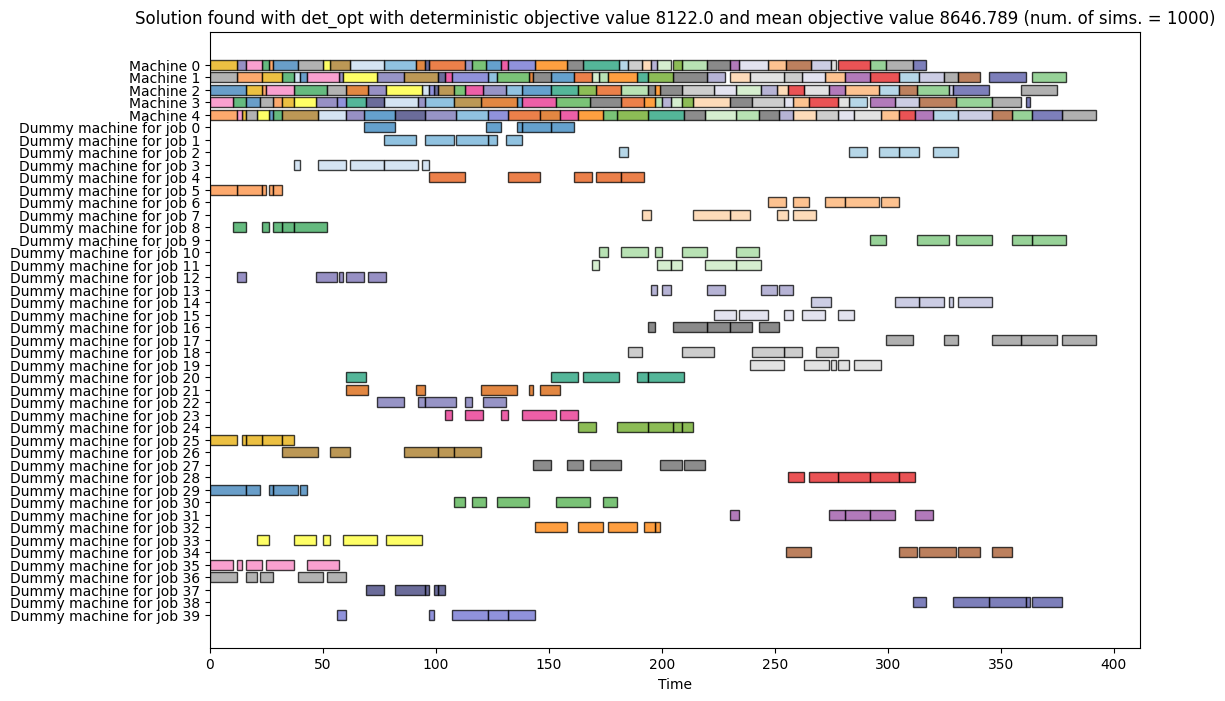

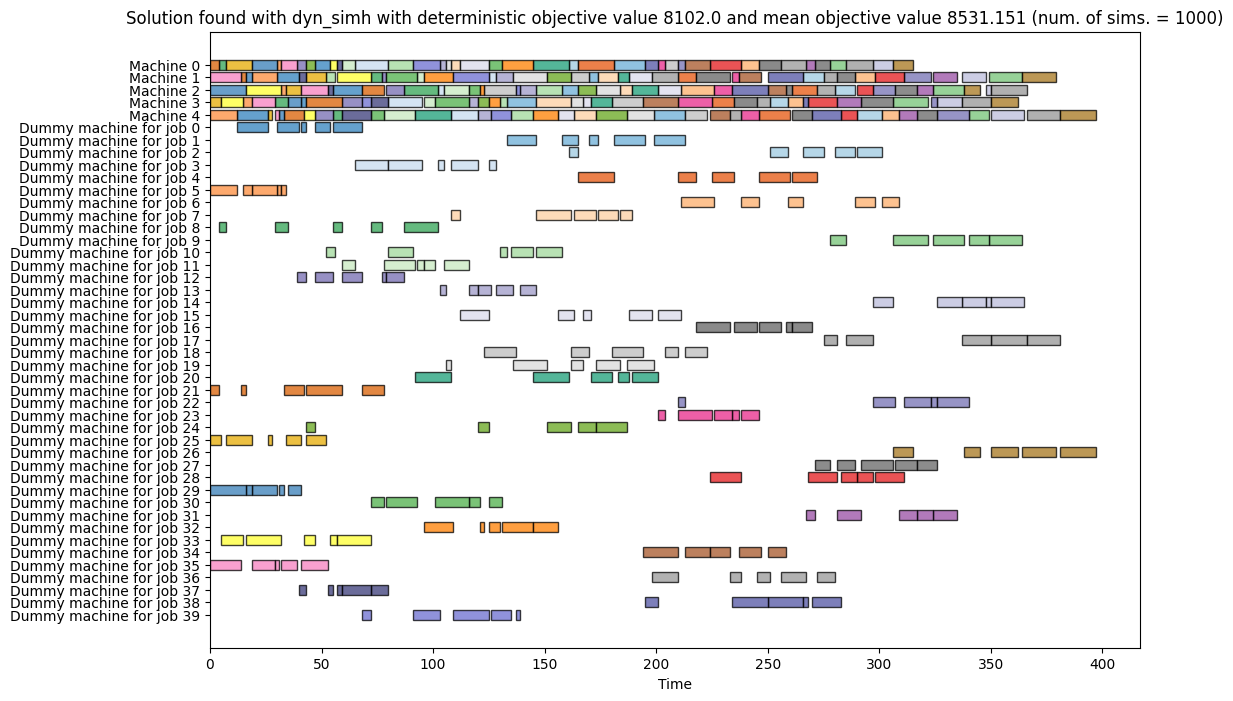

Plotting Gantt charts for ParallelMachines_2025-04-27_15-13-43.csv with seed 1


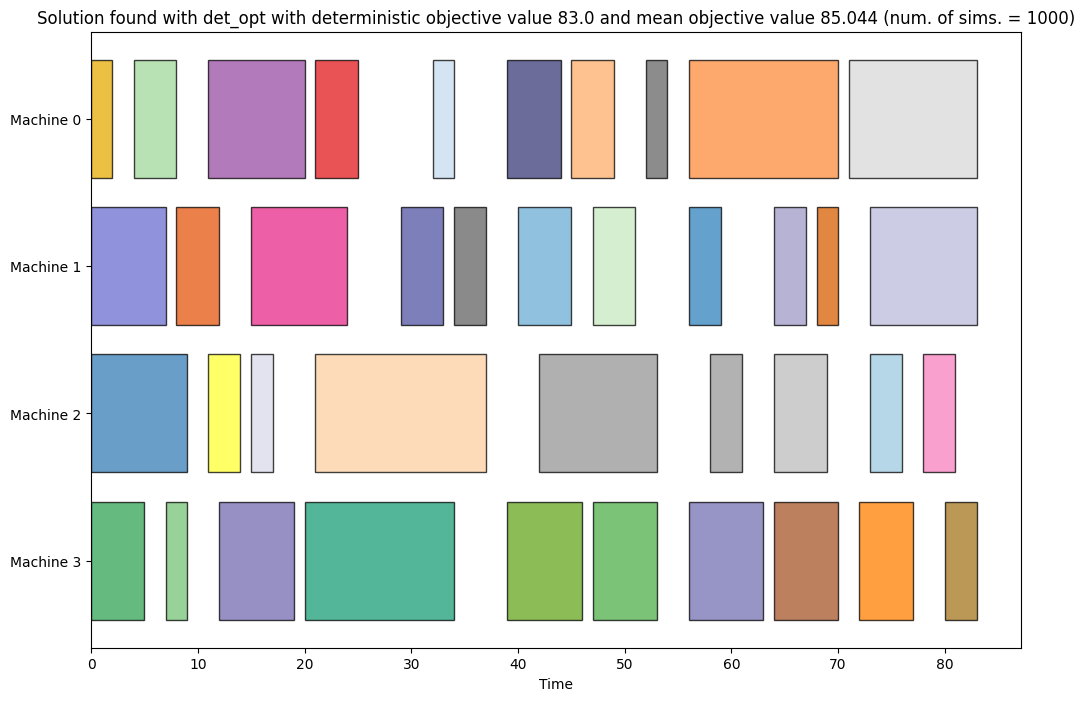

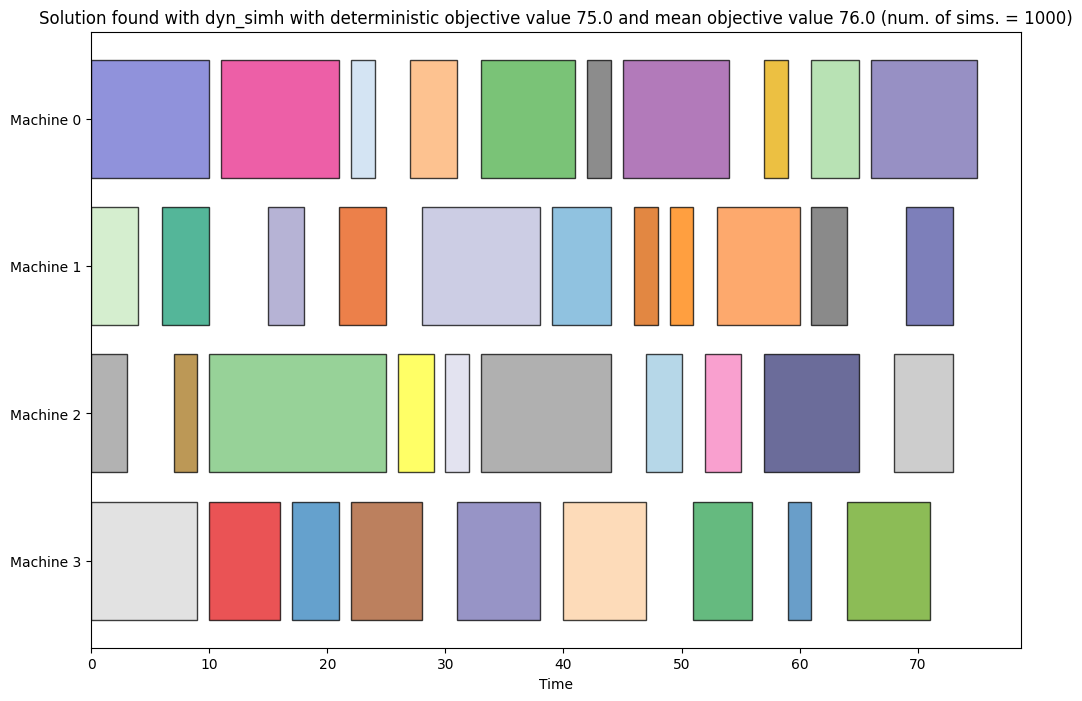

Plotting Gantt charts for HybridFlowShop_2025-04-27_15-13-25.csv with seed 1


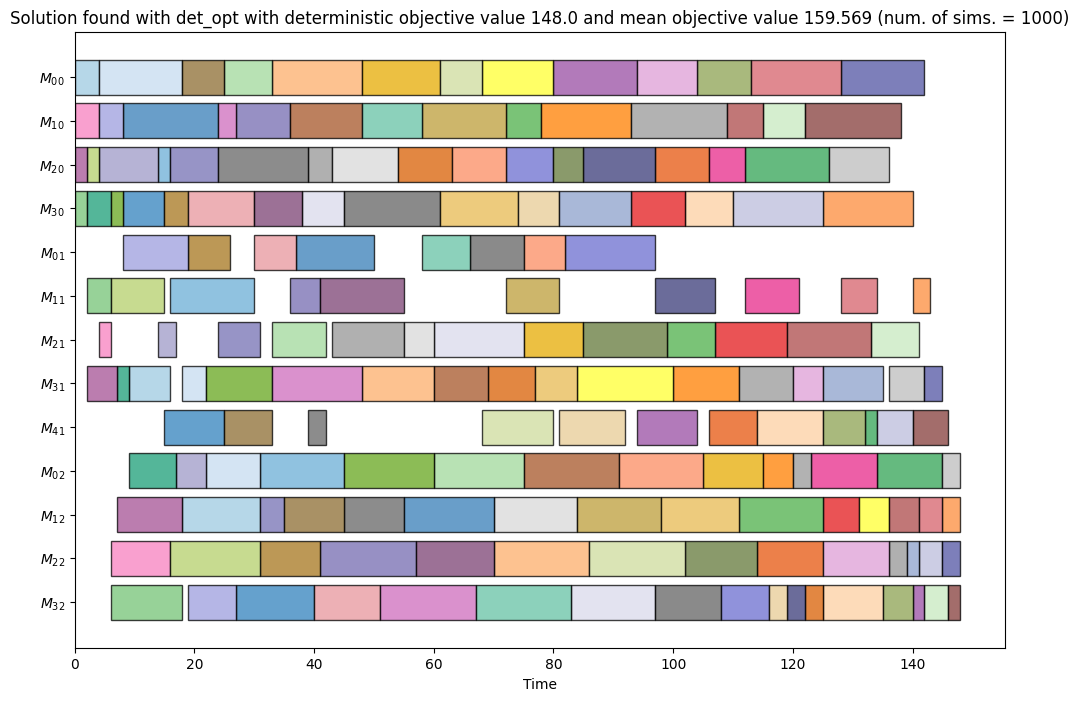

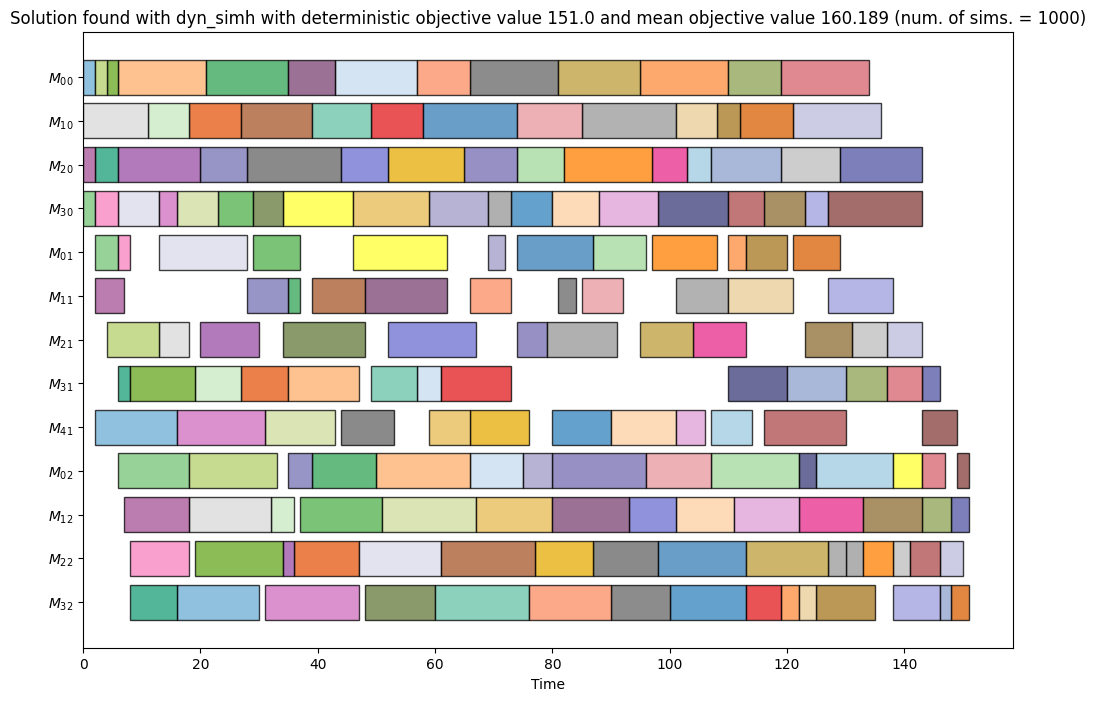

Plotting Gantt charts for JobShop_2025-04-27_15-13-14.csv with seed 1


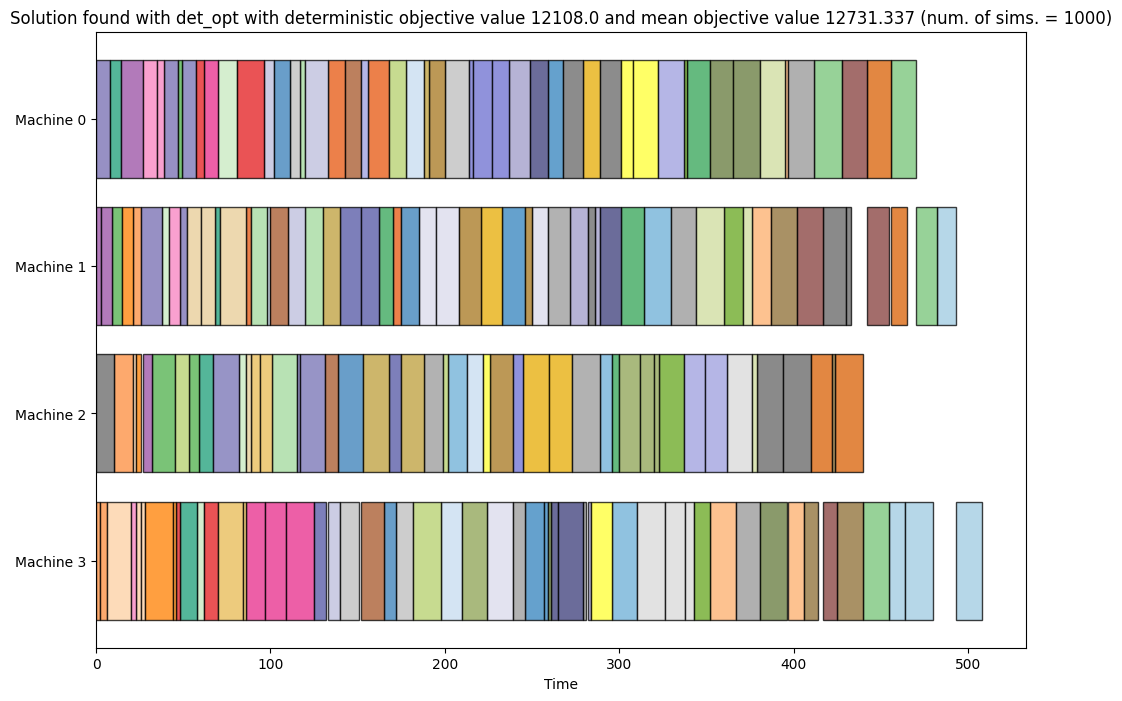

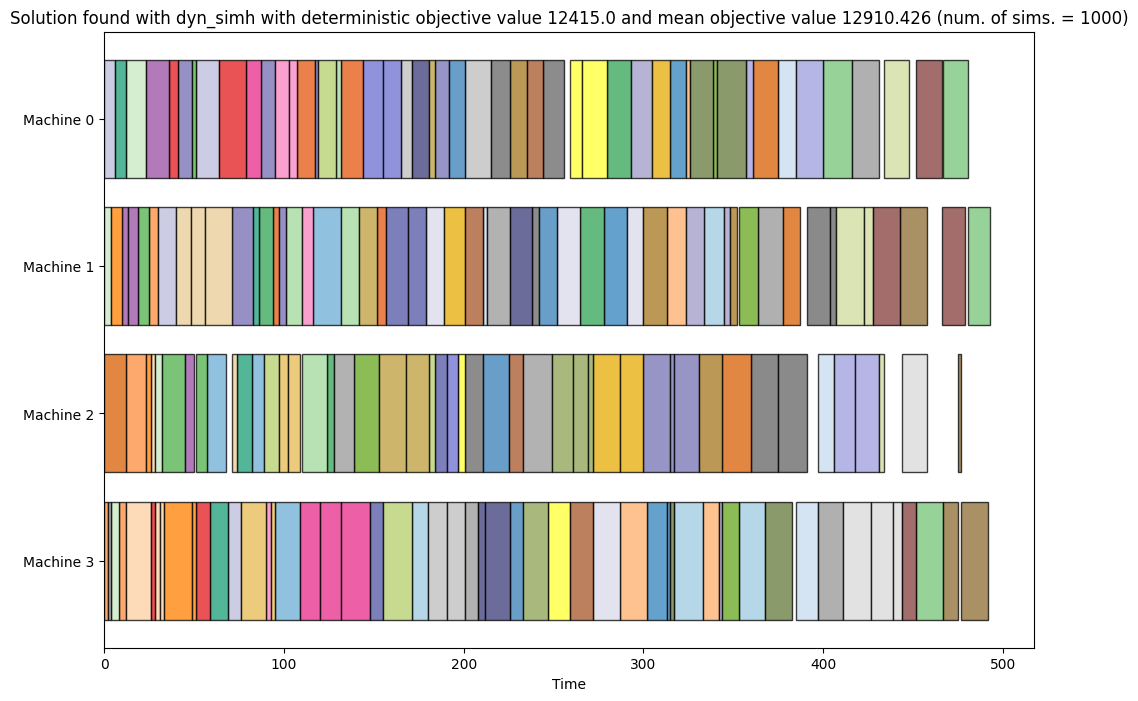

Plotting Gantt charts for FlexibleJobShop_2025-04-27_15-13-10.csv with seed 1


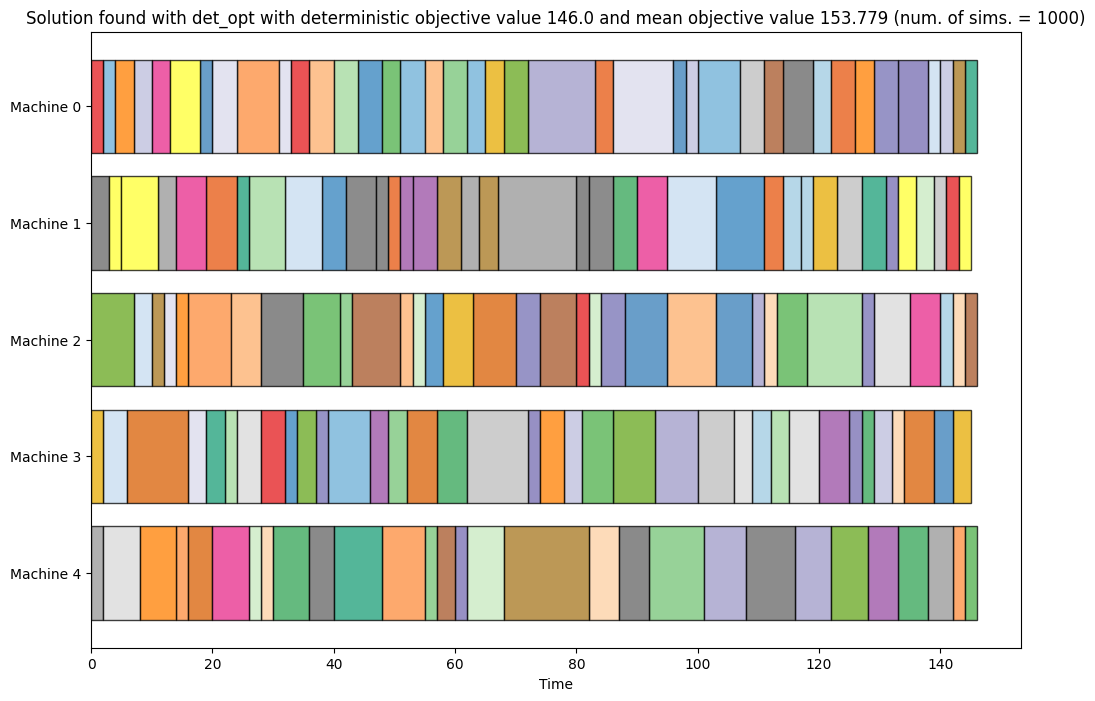

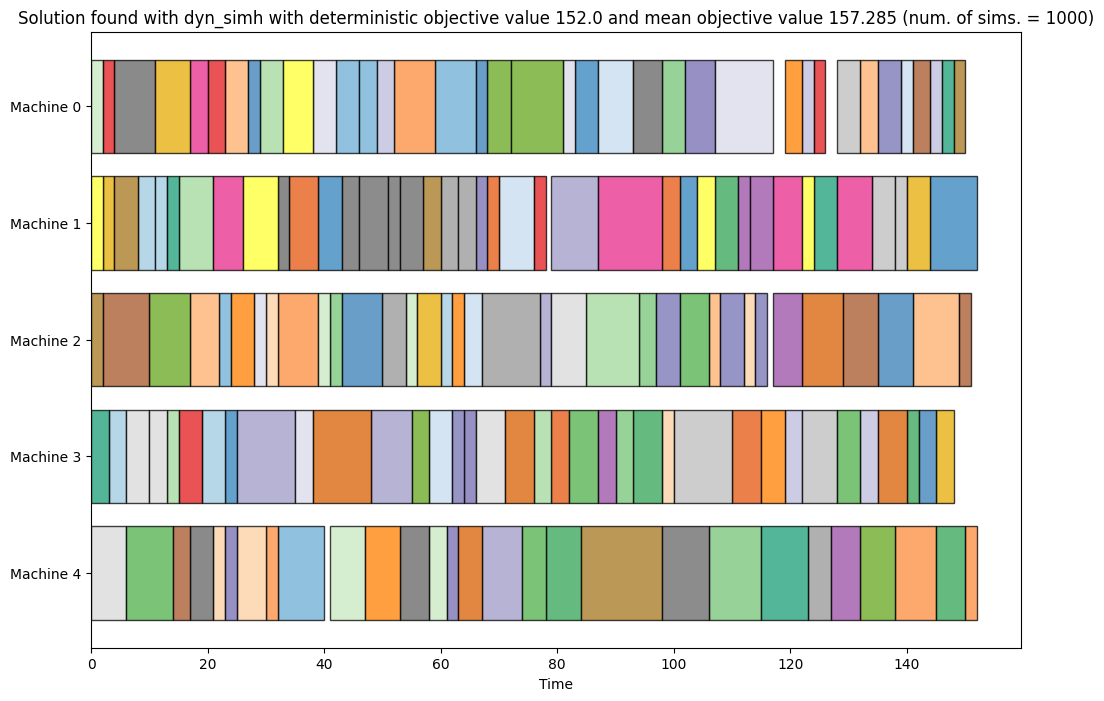

In [10]:
import numpy as np

from pyjobshop import Solution
from simpyjobshop import problems
from simpyjobshop.utils import plot_gantt_chart

seed = 1
plot_simhs = ["det_opt", "dyn_simh"]
for file_name, df in dfs.items():
    print(f"Plotting Gantt charts for {file_name} with seed {seed}")
    for simh in plot_simhs:
        filt = np.logical_and(df.seed == seed, df.simheuristic == simh)
        df_filt = df[filt]
        solution_json_str = df_filt.DCOP_solution.values[0]
        solution = Solution.from_json_str(solution_json_str)
        problem_name = file_name.split("_")[0]
        problem = getattr(problems, problem_name, None)(seed)
        if problem is None:
            raise ValueError(f"Unknown problem: {problem_name}")
        title=(
            f"Solution found with {simh} with "
            f"deterministic objective value {df_filt.DCOP_objective.values[0]}"
            f" and mean objective value {df_filt['mean'].values[0]}"
            f" (num. of sims. = {df_filt.num_sims.values[0]})"
        )
        plot_gantt_chart(solution, problem, title)

# Loading Wandb data


In [7]:
# import wandb
#
# # Init
# api = wandb.Api()
# user_name = "joost-berkhout-vrije-universiteit-amsterdam"
# keys = ["Time (in seconds)", "Objective new candidate", "Deterministic model", "Mean objective new candidate"]  # , "Deterministic model"]  # , "Best mean objective"]
#
# # Get all runs in dataframes
# dfs = {}
# file_names_without_extension = [file_name.split(".")[0] for file_name in file_names]
# for project_name in file_names_without_extension:
#     runs = api.runs(user_name + "/" + project_name)
#     for run in runs:
#         split_name = run.name.split("_")
#         seed = int(split_name[-1])
#         problem_name = split_name[0]
#         method = run.job_type
#         if method != "dyn_simh":
#             continue  # only load dyn_simh runs
#         history = run.history()
#         dfs[(problem_name, method, seed)] = history
#         # print('Run loaded:', (problem_name, method, seed, history.columns))
# # print(dfs[('OS', 'dyn_simh', 4)].head(3))

# Explore DCOP representations in dyn_simh runs

In [8]:
# import pandas as pd
#
# pd.set_option('display.max_rows', None)  # Show all rows
#
# name_mapper = {  # for wandb data logged
#     0.: "Mean",
#     0.6: "0.6-quantiles",
#     0.7: "0.7-quantiles",
#     0.8: "0.8-quantiles",
#     }
#
# # Initialize trackers for each problem and deterministic model
# repr_counter = {}
# succes_counter = {}
# mean_successes_per_attempt = {}
#
# for (problem_name, method, seed), df in dfs.items():
#
#     if method != "dyn_simh":
#         continue  # Only analyze dyn_simh runs
#
#     if problem_name not in repr_counter:
#         assert problem_name not in succes_counter
#         assert problem_name not in mean_successes_per_attempt
#         repr_counter[problem_name] = {k: 0 for k in name_mapper.keys()}
#         succes_counter[problem_name] = {k: 0 for k in name_mapper.keys()}
#         mean_successes_per_attempt[problem_name] = {k: 0 for k in name_mapper.keys()}
#
#     # Count how many times each 'Deterministic model' value appears
#     # (each time a new deter. model is used, its key is denoted, else NaN)
#     det_models = df["Deterministic model"]
#     det_models = det_models[det_models.notna()]
#     for det_model in det_models:
#         repr_counter[problem_name][det_model] += 1
#
#     # Count how often a deterministic model improved the SCOP objective
#     df['Deterministic model (ffill)'] = df['Deterministic model'].ffill()  # Forward-fill the last known 'Deterministic model' value
#     filtered = df[df['Best mean objective'].notna()].copy()  # 'Best mean objective' NaN corresponds to pre-simulation phase or new determ. model is logged
#     filtered['Improved'] = filtered['Best mean objective'].diff().lt(0)  # Identify where the 'Best mean objective' decreases (i.e., improves --> "less than")
#     improvements = filtered[filtered['Improved']]  # Keep rows where an improvement happened
#     impr_counts = improvements['Deterministic model (ffill)'].value_counts()  # Count how often each Deterministic model value led to an improvement
#     for det_model, _count in impr_counts.items():
#         succes_counter[problem_name][det_model] += _count
#
# # Calculate mean successes per attempt for each problem and deterministic model
# for problem_name in succes_counter.keys():
#     for det_model in name_mapper.keys():
#         num_succes = succes_counter[problem_name][det_model]
#         total_count = repr_counter[problem_name][det_model]
#         mean_successes_per_attempt[problem_name][det_model] = num_succes / total_count
#         assert total_count > 0
#
# # Plot pie charts with percentages
# pie_chart_data = {
#     "Number times DCOP repr. used in DynSimH": repr_counter,
#     "Number times DCOP repr. in DynSimH led to improvement": succes_counter,
#     "Mean number of improvements per DCOP repr. attempt": mean_successes_per_attempt,
#     }
# def autopct_format(values):
#     def format_fn(pct):
#         total = sum(values)
#         val = pct * total / 100.0
#         return f'{val:.1f}\n({pct:.1f}%)'
#     return format_fn
# for txt, _data in pie_chart_data.items():
#
#     # Set up the figure and axes for a 2x3 grid
#     fig, axes = plt.subplots(2, 3, figsize=(10, 5))
#     axes = axes.flatten()  # Flatten to easily iterate over
#
#     # Plot a pie chart for each problem type
#     colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
#     for idx, (problem_type, values) in enumerate(_data.items()):
#         labels = [name_mapper[key] for key in values.keys()]
#         sizes = list(values.values())
#         axes[idx].pie(sizes, labels=labels, colors=colors, autopct=autopct_format(sizes), startangle=90)
#         axes[idx].set_title(problem_type, fontsize=14, fontweight='bold')
#         axes[idx].axis('equal')  # Equal aspect ratio ensures pie is circular
#
#     # Finalize figure
#     fig.delaxes(axes[-1])  # Remove the last (empty) subplot
#     plt.tight_layout()  # Adjust layout to prevent overlap
#     extra_txt = "with tardiness" if b_with_tardiness else "without tardiness"
#     extra_txt += " & full stochasticity" if b_full_stochasticity else " & partial stochasticity"
#     plt.suptitle(f'{txt} ({extra_txt})', fontsize=14, fontweight='bold', y=1.05)
#     plt.show()